## Water-Potability ML Model

Importing required liabraries

In [113]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,roc_auc_score, roc_curve, classification_report
from sklearn import metrics
from xgboost import XGBClassifier

**importing liabrary to handle missing and balancing data and value in the dataset**

In [34]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

**importing more liabraries for models:**

In [35]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

importing liabraries for visulation**

In [108]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import pydotplus

importing liabraries for hyperparameter tuning

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

Reading csv file

In [38]:
df=pd.read_csv('water_potability.csv')

Checking head values in dataset

In [39]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


,count
Potability,
0,1998
1,1278


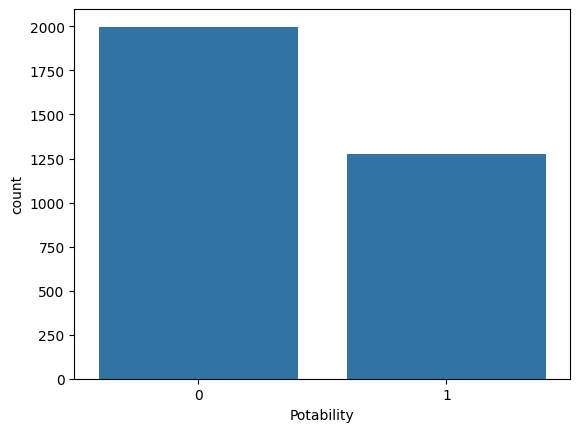

In [41]:
sns.countplot(data=df,x=df.Potability)
df.Potability.value_counts()

Checking missing values in dataset

In [42]:
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


checking out liers

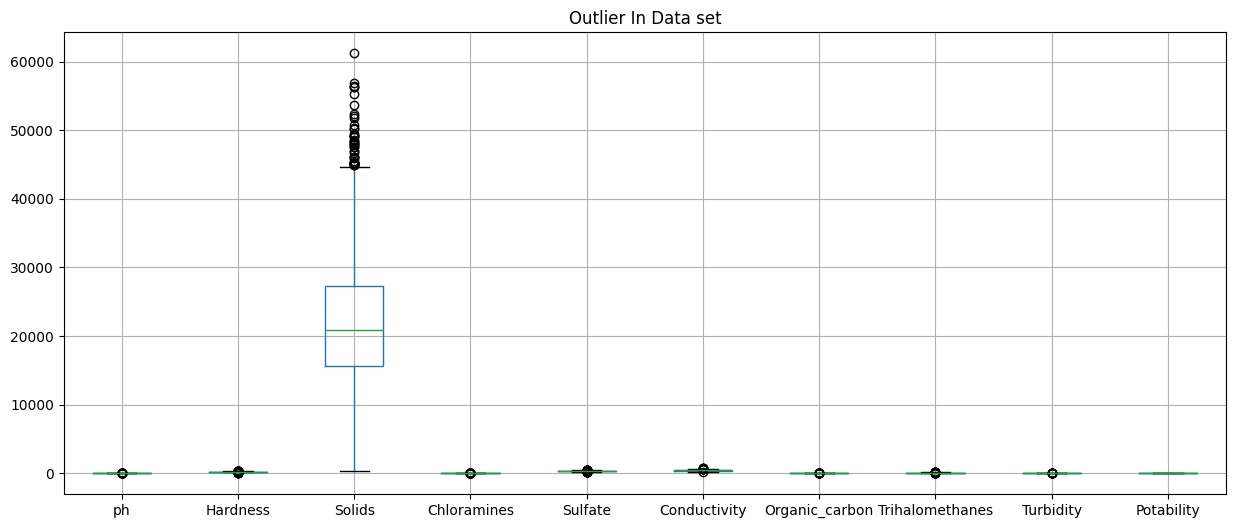

In [43]:
graph=df.select_dtypes(include=["float64", "int64"])
plt.figure(figsize=(15, 6))
graph.boxplot()
plt.title("Outlier In Data set")
plt.show()

Filling missing value by using Mean in columns

In [44]:
df['ph'].fillna(df['ph'].mean(), inplace=True)
df['Sulfate'].fillna(df['Sulfate'].mean(), inplace=True)
df['Trihalomethanes'].fillna(df['Trihalomethanes'].mean(), inplace=True)

/tmp/ipython-input-2876935244.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ph'].fillna(df['ph'].mean(), inplace=True)
/tmp/ipython-input-2876935244.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [45]:
df.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


removing outliers

In [46]:
for col in df.columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    df = df[(df[col] >= q1 - 1.5 * iqr) & (df[col] <= q3 + 1.5 * iqr)]


**Performing Feature Scaling**

In [112]:
X = df.drop('Potability', axis=1)
y = df['Potability']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=58)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Handling Class Imbalance Using SMOTE**

In [48]:
smote = SMOTE(random_state=60)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

**Model Selection & Data Splitting**

## 1st model: Decision Tree with F1-score, AUC-ROC, Confusion Matrix

Initializing the decision tree model

In [49]:
dtree = DecisionTreeClassifier(random_state=55)

fitting model with training data

In [50]:
dtree.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(random_state=55)

scaling test data

In [51]:
y_pred_dtree = dtree.predict(X_test_scaled)
y_prob_dtree = dtree.predict_proba(X_test_scaled)[:, 1]

evaluating matrix

In [52]:
cm_dtree = confusion_matrix(y_test, y_pred_dtree)
accuracy_dtree = accuracy_score(y_test, y_pred_dtree)
precision_dtree = precision_score(y_test, y_pred_dtree)
recall_dtree = recall_score(y_test, y_pred_dtree)
f1_dtree = f1_score(y_test, y_pred_dtree)
roc_auc_dtree = roc_auc_score(y_test, y_prob_dtree)

**visulation & performance**

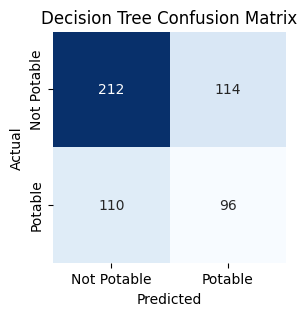

               
Details about model: 
Accuracy: 0.58
Precision: 0.46
Recall: 0.47
F1-score: 0.46
AUC-ROC score: 0.56


In [53]:
'''ploting confusion matrix'''
plt.figure(figsize=(3,3))
sns.heatmap(cm_dtree, annot=True, fmt="d", cmap="Blues", cbar=False,xticklabels=['Not Potable', 'Potable'], yticklabels=['Not Potable', 'Potable'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()
print('               ')
print('Details about model: ')
print(f"Accuracy: {accuracy_dtree:.2f}")
print(f"Precision: {precision_dtree:.2f}")
print(f"Recall: {recall_dtree:.2f}")
print(f"F1-score: {f1_dtree:.2f}")
print(f"AUC-ROC score: {roc_auc_dtree:.2f}")

## 2nd model: Random forest with F1-score, AUC-ROC, Confusion Matrix

Initializing the random forest model

In [54]:
rf_model = RandomForestClassifier(random_state=52)

fitting the model with training data

In [55]:
rf_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=52)

scaling test data to model

In [56]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

evaluating the matrix

In [57]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

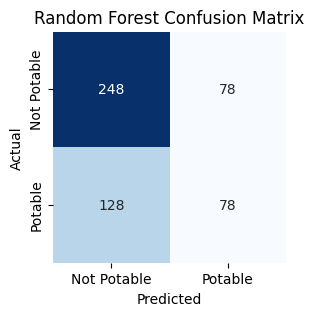

               
Details about model: 
Accuracy: 0.61
Precision: 0.50
Recall: 0.38
F1-score: 0.43
AUC-ROC score: 0.60


In [58]:
'''ploting confusion matrix'''
plt.figure(figsize=(3,3))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", cbar=False,xticklabels=['Not Potable', 'Potable'], yticklabels=['Not Potable', 'Potable'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()
print('               ')
print('Details about model: ')
print(f"Accuracy: {accuracy_rf:.2f}")
print(f"Precision: {precision_rf:.2f}")
print(f"Recall: {recall_rf:.2f}")
print(f"F1-score: {f1_rf:.2f}")
print(f"AUC-ROC score: {roc_auc_rf:.2f}")

## 3nd model: SVM with F1-score, AUC-ROC, Confusion Matrix

Initializing SVM model

In [59]:
svm_classifier = SVC(kernel='rbf', C=1, random_state=15,probability=True)
svm_classifier.fit(X_train_resampled, y_train_resampled)

SVC(C=1, probability=True, random_state=15)

Scaling test data and making predictions

In [60]:
y_pred_svm = svm_classifier.predict(X_test_scaled)
y_prob_svm = svm_classifier.predict_proba(X_test_scaled)[:, 1]

Evaluating metrics for the SVM model

In [61]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

**Visualization & Performance of  SVM Model**

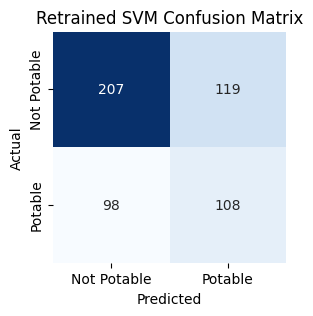

               
Details about retrained SVM model: 
Accuracy: 0.59
Precision: 0.48
Recall: 0.52
F1-score: 0.50
AUC-ROC score: 0.64


In [62]:
'''Plotting confusion matrix for retrained SVM'''
plt.figure(figsize=(3,3))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues", cbar=False,xticklabels=['Not Potable', 'Potable'], yticklabels=['Not Potable', 'Potable'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Retrained SVM Confusion Matrix')
plt.show()
print('               ')
print('Details about retrained SVM model: ')
print(f"Accuracy: {accuracy_svm:.2f}")
print(f"Precision: {precision_svm:.2f}")
print(f"Recall: {recall_svm:.2f}")
print(f"F1-score: {f1_svm:.2f}")
print(f"AUC-ROC score: {roc_auc_svm:.2f}")

## 4 model-K-nearest Neighbors(KNN) with F1-score, AUC-ROC, confusion matrix

Initializing the KNN model

In [63]:
knn_model = KNeighborsClassifier(n_neighbors=76)

Fitting the model with training data

In [64]:
knn_model.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier(n_neighbors=76)

Scaling test data and making predictions

In [65]:
y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

Evaluating the metrics

In [66]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)

**Visualization & Performance of KNN Model**

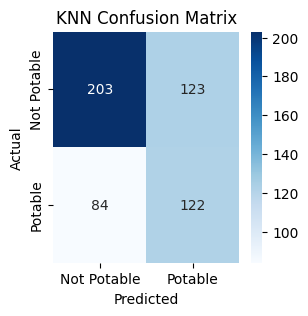

               
Details about KNN model: 
Accuracy: 0.61
Precision: 0.50
Recall: 0.59
F1-score: 0.54
AUC-ROC score: 0.63


In [67]:
'''Plotting confusion matrix for KNN'''
plt.figure(figsize=(3,3))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues", cbar=True,xticklabels=['Not Potable', 'Potable'], yticklabels=['Not Potable', 'Potable'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')
plt.show()
print('               ')
print('Details about KNN model: ')
print(f"Accuracy: {accuracy_knn:.2f}")
print(f"Precision: {precision_knn:.2f}")
print(f"Recall: {recall_knn:.2f}")
print(f"F1-score: {f1_knn:.2f}")
print(f"AUC-ROC score: {roc_auc_knn:.2f}")

## 5th model: XGBoost Classifier with F1-score, AUC-ROC, Confusion Matrix

Initializing the XGBoost model

In [69]:
xgb_model=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=50)

Fitting the model with training data

In [70]:
xgb_model.fit(X_train_resampled, y_train_resampled)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:42:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Making predictions on test data

In [71]:
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

Evaluating the metrics

In [72]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

**Visualization & Performance of XGBoost Model**

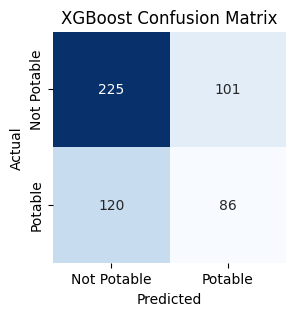

               
Details about XGBoost model: 
Accuracy: 0.58
Precision: 0.46
Recall: 0.42
F1-score: 0.44
AUC-ROC score: 0.58


In [73]:
'''Plotting confusion matrix for XGBoost'''
plt.figure(figsize=(3,3))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", cbar=False,xticklabels=['Not Potable', 'Potable'], yticklabels=['Not Potable', 'Potable'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()
print('               ')
print('Details about XGBoost model: ')
print(f"Accuracy: {accuracy_xgb:.2f}")
print(f"Precision: {precision_xgb:.2f}")
print(f"Recall: {recall_xgb:.2f}")
print(f"F1-score: {f1_xgb:.2f}")
print(f"AUC-ROC score: {roc_auc_xgb:.2f}")

hyperparameter tuning FOR RANDOM FOREST



In [74]:
param_grid = {"n_estimators": [100, 200, 300],"max_depth": [None, 10, 20, 30],
              "min_samples_split": [2, 5, 10],"min_samples_leaf": [1, 2, 4],
              "bootstrap": [True, False] }

In [75]:
grid_sec = GridSearchCV(estimator=rf_model,param_grid=param_grid,cv=5,scoring="accuracy",n_jobs=-1,verbose=1)

In [76]:
grid_sec.fit(X_train, y_train)

'grid_search.fit(X_train, y_train)'

In [77]:
best_params = grid_sec.best_params_
print (f"Best Hyperparameters:{best_params}")

'best_params = grid_search.best_params_\nprint (f"Best Hyperparameters:{best_params}")'

In [78]:
new_rf = RandomForestClassifier(**best_params,random_state=64)
new_rf.fit(X_train, y_train)

'new_rf = RandomForestClassifier(**best_params,random_state=64)\nnew_rf.fit(X_train, y_train)'

In [79]:
y_pred = new_rf.predict(X_test)

'y_pred = new_rf.predict(X_test)'

In [80]:
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy of Tuned Random Forest:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

'accuracy = accuracy_score(y_test, y_pred)\nprint("\nAccuracy of Tuned Random Forest:", accuracy)\nprint("\nClassification Report:")\nprint(classification_report(y_test, y_pred))'

hyperparameter tuning for xg boost


In [81]:
X = df.drop("Potability", axis=1)
y = df["Potability"]


In [82]:
xgb_model = XGBClassifier(objective="binary:logistic",eval_metric="logloss",use_label_encoder=False,random_state=50)

In [83]:
param_grid = {"n_estimators": [100, 200], "max_depth": [3, 5, 7], "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],"colsample_bytree": [0.8, 1.0]}

In [84]:
grid_search = GridSearchCV(estimator=xgb_model,param_grid=param_grid,cv=5,scoring="accuracy",n_jobs=-1,verbose=1)

In [85]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:43:39] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=1)

In [86]:
best_xgb = XGBClassifier(**grid_search.best_params_,objective="binary:logistic",eval_metric="logloss",use_label_encoder=False,random_state=42)
best_xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:43:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [87]:
y_pred = best_xgb.predict(X_test)

In [120]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy of Tuned XGBoost Model:", accuracy)
print("over all report:")
print(classification_report(y_test, y_pred))

Accuracy of Tuned XGBoost Model: 0.6109022556390977
over all report:
              precision    recall  f1-score   support

           0       0.64      0.88      0.74       336
           1       0.42      0.14      0.21       196

    accuracy                           0.61       532
   macro avg       0.53      0.51      0.48       532
weighted avg       0.56      0.61      0.55       532



hyper tuning for svm

In [89]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:44:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=1)

In [90]:
print("Best Hyperparameters:")
print(grid_search.best_params_)


Best Hyperparameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}


In [91]:
best_svm = grid_search.best_estimator_
best_svm.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:44:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [92]:
y_pred = best_svm.predict(X_test)

In [119]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of Tuned SVM Model:", accuracy)

print("over all report:")
print(classification_report(y_test, y_pred))

Accuracy of Tuned SVM Model: 0.6109022556390977
over all report:
              precision    recall  f1-score   support

           0       0.64      0.88      0.74       336
           1       0.42      0.14      0.21       196

    accuracy                           0.61       532
   macro avg       0.53      0.51      0.48       532
weighted avg       0.56      0.61      0.55       532



decision tree hypertining

In [94]:
dtree_model = DecisionTreeClassifier(random_state=55)
param_grid_dtree = { "max_depth": [None, 5, 10, 15], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]}
grid_search_dtree = GridSearchCV(estimator=dtree_model,param_grid=param_grid_dtree,cv=5,scoring="accuracy",n_jobs=-1,verbose=1)
grid_search_dtree.fit(X_train_resampled, y_train_resampled)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=55), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy', verbose=1)

In [115]:
print("Best Hyperparameters:")
print(grid_search_dtree.best_params_)

Best Hyperparameters:
{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [96]:
best_dt = DecisionTreeClassifier(**grid_search_dtree.best_params_,random_state=63)

In [97]:
best_dt.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(min_samples_split=5, random_state=42)

In [98]:
y_pred = best_dt.predict(X_test_scaled)

In [117]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of Tuned Decision Tree Model:", accuracy)

print("over all report:")
print(classification_report(y_test, y_pred))

Accuracy of Tuned Decision Tree Model: 0.6109022556390977
over all report:
              precision    recall  f1-score   support

           0       0.64      0.88      0.74       336
           1       0.42      0.14      0.21       196

    accuracy                           0.61       532
   macro avg       0.53      0.51      0.48       532
weighted avg       0.56      0.61      0.55       532



hyperparameter tuning for knn

In [100]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:46:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=1)

In [101]:
print("Best Hyperparameters:")
print(grid_search.best_params_)

Best Hyperparameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}


In [102]:
best_knn = grid_search.best_estimator_
best_knn.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:46:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [103]:
y_pred = best_knn.predict(X_test)

In [118]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of Tuned KNN Model:", accuracy)

print("over all report:")
print(classification_report(y_test, y_pred))

Accuracy of Tuned KNN Model: 0.6109022556390977
over all report:
              precision    recall  f1-score   support

           0       0.64      0.88      0.74       336
           1       0.42      0.14      0.21       196

    accuracy                           0.61       532
   macro avg       0.53      0.51      0.48       532
weighted avg       0.56      0.61      0.55       532



comparision of all models

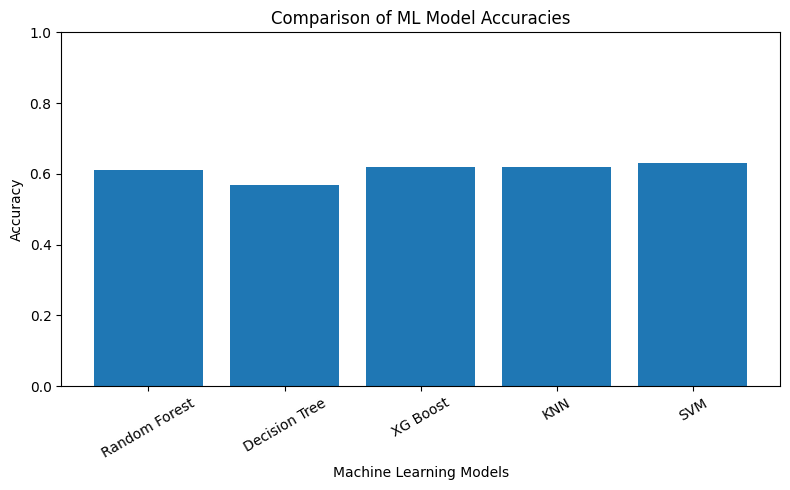

In [116]:
models = ["Random Forest","Decision Tree","XG Boost","KNN","SVM"]
accuracies = [0.61,0.57,0.62,0.62,0.63]

# Plotting the comparison graph
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.title("Comparison of ML Model Accuracies")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**SVM visualizations after performing hyper parameter tuning**



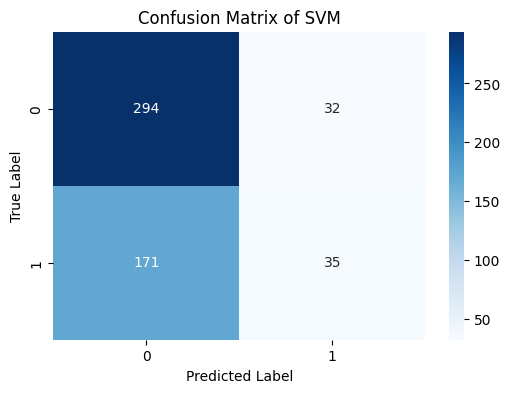

In [106]:
y_pred = best_svm.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix of SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


**creating auc roc visulation to check the model over all performance**

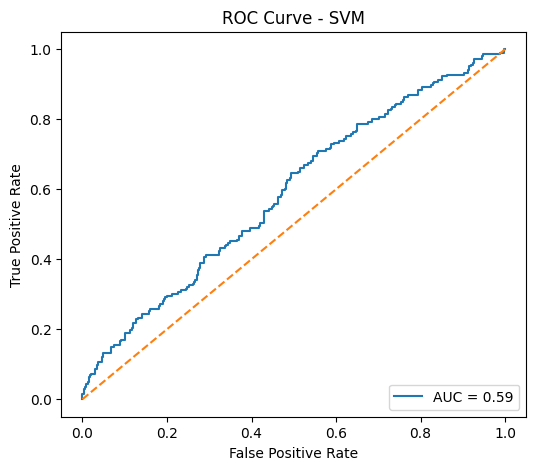

In [109]:
y_prob = best_svm.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label="AUC = {:.2f}".format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend(loc="lower right")
plt.show()

creating het map to get over all overview of all elements relation

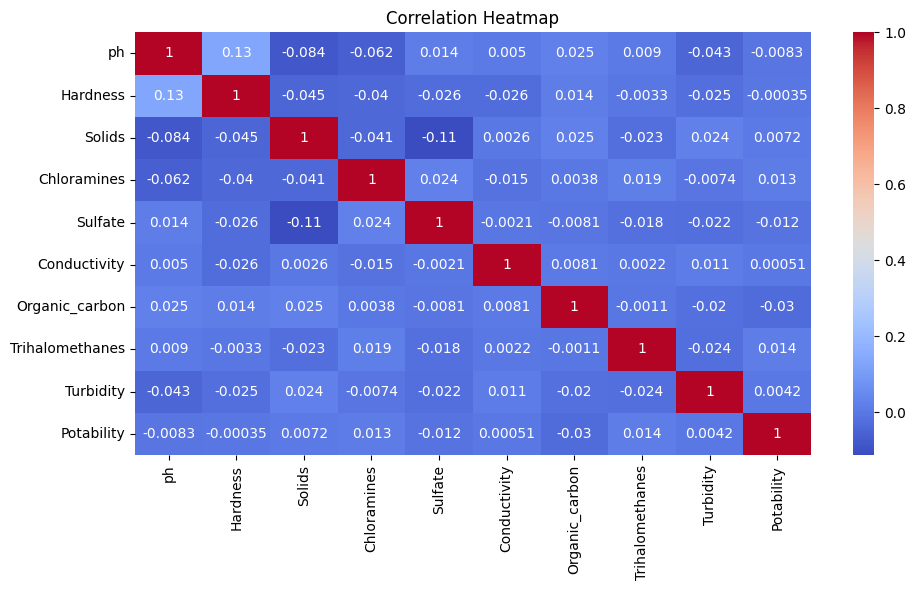

In [110]:
heatmap=df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
